In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, mannwhitneyu
from scipy.stats import pearsonr
from scipy.stats import spearmanr

In [2]:
import random
from datetime import datetime, timedelta

In [4]:
!pip install xlsxwriter

In [5]:
# Загружаем все листы в словарь
dfs = pd.read_excel("Dataset_AB-test_update.xlsx", sheet_name=None)  

In [6]:
# Формируем первый датафрейм с данными из первого листа
df_data = dfs['Данные']
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37989 entries, 0 to 37988
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_order     37989 non-null  int64         
 1   id_client    37401 non-null  float64       
 2   amt_payment  35845 non-null  float64       
 3   dtime_pay    35560 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 1.2 MB


In [13]:
# В этой таблице id_client имеет тип float64. Изменим его на Int64 во избежание проблем при соединении с другими таблицами
df_data['id_client'] = df_data['id_client'].astype('Int64')

В датафрейме есть пропущенные значения - эти строки будут удалены. 

In [15]:
df_data_nn =df_data.dropna()
df_data_nn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35560 entries, 0 to 37988
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_order     35560 non-null  int64         
 1   id_client    35560 non-null  Int64         
 2   amt_payment  35560 non-null  float64       
 3   dtime_pay    35560 non-null  datetime64[ns]
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(1)
memory usage: 1.4 MB


In [17]:
## Процент удаленных данных (если убрать все строки с нулевыми значениями): 
1-len(df_data_nn) / len (df_data)

0.0639395614519993

In [19]:
# Посмотрим на характеристики числовых значений датафрейма и на распределение данных на предмет выбросов
df_data_nn.describe()

,id_order,id_client,amt_payment,dtime_pay
count,35560.000000,35560.0,35560.000000,35560
mean,197768.890804,194089.864511,3542.339623,2022-07-15 06:05:14.001493248
min,100238.000000,178561.0,498.000000,2022-06-04 02:51:21.878000
25%,148567.000000,186352.75,2581.000000,2022-06-25 22:28:13.217499904
50%,197639.500000,194074.5,3470.000000,2022-07-15 04:35:15.531500032
75%,246340.500000,201863.25,4390.000000,2022-08-03 14:11:16.191000064
max,297607.000000,209634.0,7633.000000,2022-08-29 10:21:05.025000
std,56689.034409,8973.216267,1427.383578,NaN


Text(0, 0.5, 'Суммы покупок')

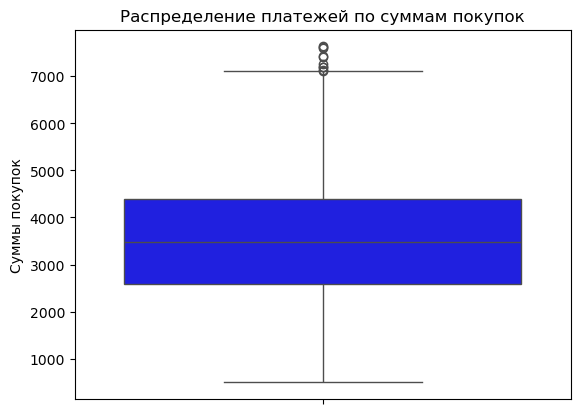

In [20]:
ax0 = sns.boxplot(df_data_nn['amt_payment'], color = 'blue')
ax0.axes.set_title("Распределение платежей по суммам покупок")
ax0.set_ylabel("Суммы покупок")

In [14]:
## Удалим вероятные выбросы в суммах покупок
Q1 = np.percentile(df_data_nn['amt_payment'], 25)
Q3 = np.percentile(df_data_nn['amt_payment'], 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print (lower_bound, upper_bound)

-132.5 7103.5


In [22]:
df_data_cl = df_data_nn.loc[df_data_nn['amt_payment'] < upper_bound].copy()
df_data_cl.describe()
## В результате удалены еще 10 строк

,id_order,id_client,amt_payment,dtime_pay
count,35550.000000,35550.0,35550.000000,35550
mean,197774.587736,194089.031899,3541.266245,2022-07-15 06:02:29.033880320
min,100238.000000,178561.0,498.000000,2022-06-04 02:51:21.878000
25%,148576.250000,186352.25,2580.000000,2022-06-25 22:27:57.236500224
50%,197661.500000,194072.5,3470.000000,2022-07-15 04:29:58.168499968
75%,246341.500000,201861.75,4388.000000,2022-08-03 14:10:08.554500096
max,297607.000000,209634.0,7099.000000,2022-08-29 10:21:05.025000
std,56687.983031,8973.404319,1426.144829,NaN


In [28]:
## Построим гистограмму распределения сумм покупок

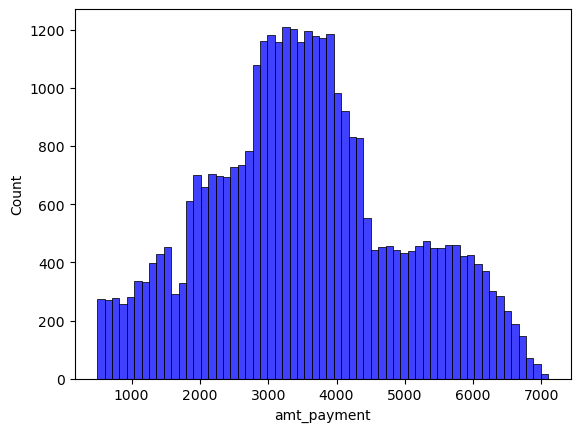

In [30]:
ax1 = sns.histplot(df_data_cl['amt_payment'], color = 'blue')

In [ ]:
## Проверим нормальность распределения сумм покупок с помощью правила 3-х сигм

In [32]:
m = df_data_cl['amt_payment'].mean() # Среднее значение чисел из amt_payment
s = df_data_cl['amt_payment'].std() # Разброс чисел из amt_payment

print('Среднее = ', m)
print('Сигма = ', s)

Среднее =  3541.2662447257385
Сигма =  1426.1448289885634


In [34]:
df_one_sigma = df_data_cl[(df_data_cl['amt_payment'] >= m - s) & (df_data_cl['amt_payment'] <= m + s)]
df_two_sigma = df_data_cl[(df_data_cl['amt_payment'] >= m - 2*s) & (df_data_cl['amt_payment'] <= m + 2*s)]
df_three_sigma = df_data_cl[(df_data_cl['amt_payment'] >= m - 3*s) & (df_data_cl['amt_payment'] <= m + 3*s)]

In [36]:
print('Доля наблюдений в 1 сигме', df_one_sigma.count()['id_order']   / df_data_cl.count()['id_order'])
print('Доля наблюдений в 2 сигмах', df_two_sigma.count()['id_order']   / df_data_cl.count()['id_order'])
print('Доля наблюдений в 3 сигмах', df_three_sigma.count()['id_order'] / df_data_cl.count()['id_order'])

Доля наблюдений в 1 сигме 0.6554430379746835
Доля наблюдений в 2 сигмах 0.9627004219409283
Доля наблюдений в 3 сигмах 1.0


In [38]:
# Наблюдения, которые попадают в хвосты распределения, не превышают 0,3%. Значит, наше распределение нормальное.

In [16]:
## Второй датафрейм со второго листа файла
df_client = dfs['Clients']
df_client.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55605 entries, 0 to 55604
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_client         55605 non-null  int64         
 1   dtime_ad          55356 non-null  datetime64[ns]
 2   nflag_test        55605 non-null  int64         
 3   id_trading_point  55605 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 1.7 MB


In [18]:
## Есть небольшое количество нулевых значений дат показа рекламы. Удалим эти строки
df_client_nn = df_client.dropna()
df_client_nn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55356 entries, 0 to 55604
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_client         55356 non-null  int64         
 1   dtime_ad          55356 non-null  datetime64[ns]
 2   nflag_test        55356 non-null  int64         
 3   id_trading_point  55356 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 2.1 MB


In [24]:
# Выполним группировку покупок по клиентам
df_gr = df_data_cl.groupby('id_client').agg(sum_pay = ('amt_payment', 'sum')).reset_index()

In [46]:
df_gr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28377 entries, 0 to 28376
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id_client  28377 non-null  Int64  
 1   sum_pay    28377 non-null  float64
dtypes: Int64(1), float64(1)
memory usage: 471.2 KB


In [26]:
## Выполним объединение двух датафреймов right, чтобы не потерять клиентов,которые видели рекламу,  
## но покупок не совершили, но исключить клиентов, которые делали покупки, но не участваовали в тестировании
df_all = df_gr.merge(df_client_nn, on = 'id_client', how = 'right')
df_all.head()

,id_client,sum_pay,dtime_ad,nflag_test,id_trading_point
0,180844,5349.0,2022-06-08 18:38:41.414,0,212
1,226069,NaN,2022-07-11 16:28:38.511,1,54
2,183981,6322.0,2022-06-16 12:23:59.289,1,991
3,322530,NaN,2022-07-08 08:56:08.714,0,1015
4,254313,NaN,2022-06-19 22:18:01.770,1,453


In [50]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55356 entries, 0 to 55355
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_client         55356 non-null  Int64         
 1   sum_pay           28377 non-null  float64       
 2   dtime_ad          55356 non-null  datetime64[ns]
 3   nflag_test        55356 non-null  int64         
 4   id_trading_point  55356 non-null  int64         
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(2)
memory usage: 2.2 MB


In [52]:
# Клиенты, не участвовавшие в тесте, исключены из дф автоматически за счет использования объединения right
df_all[(~df_all['id_client'].isnull()) & (df_all['dtime_ad'].isnull())]

,id_client,sum_pay,dtime_ad,nflag_test,id_trading_point


In [160]:
## Проверим, все ли клиенты из клиентской таблицы присутствуют в итоговом датафрейме
is_present = set(df_client_nn['id_client'].unique().tolist()).issubset(df_all['id_client'])
is_present ## Да, все присутствуют

True

In [28]:
# Заполним нулевым значением строки с отсутствующей суммой покупки (т.е. там, где покупка не совершена)
df_all['sum_pay'] = df_all['sum_pay'].fillna(0) 
df_all.head()

,id_client,sum_pay,dtime_ad,nflag_test,id_trading_point
0,180844,5349.0,2022-06-08 18:38:41.414,0,212
1,226069,0.0,2022-07-11 16:28:38.511,1,54
2,183981,6322.0,2022-06-16 12:23:59.289,1,991
3,322530,0.0,2022-07-08 08:56:08.714,0,1015
4,254313,0.0,2022-06-19 22:18:01.770,1,453


In [30]:
# Проставим флаги: 1 - покупка совершена, 0 - покупки не было
df_all['flag_pay'] = np.where(df_all['sum_pay'] == 0, 0, 1)
df_all.head()

,id_client,sum_pay,dtime_ad,nflag_test,id_trading_point,flag_pay
0,180844,5349.0,2022-06-08 18:38:41.414,0,212,1
1,226069,0.0,2022-07-11 16:28:38.511,1,54,0
2,183981,6322.0,2022-06-16 12:23:59.289,1,991,1
3,322530,0.0,2022-07-08 08:56:08.714,0,1015,0
4,254313,0.0,2022-06-19 22:18:01.770,1,453,0


In [32]:
## Третий датафрейм с третьего листа файла
df_region = dfs['Region_dict']
df_region.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id_trading_point  66 non-null     int64 
 1   city              66 non-null     object
dtypes: int64(1), object(1)
memory usage: 1.2+ KB


In [34]:
# Добавим из справочника к рабочему датафрейму названия городов, где расположены соответствующие торг.точки
df_all_c = df_all.merge(df_region, on = 'id_trading_point', how = 'left')
df_all_c.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55356 entries, 0 to 55355
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_client         55356 non-null  Int64         
 1   sum_pay           55356 non-null  float64       
 2   dtime_ad          55356 non-null  datetime64[ns]
 3   nflag_test        55356 non-null  int64         
 4   id_trading_point  55356 non-null  int64         
 5   flag_pay          55356 non-null  int32         
 6   city              55356 non-null  object        
dtypes: Int64(1), datetime64[ns](1), float64(1), int32(1), int64(2), object(1)
memory usage: 2.8+ MB


In [41]:
writer = pd.ExcelWriter("df_dataclean_merged.xlsx", engine="xlsxwriter")
df_all_c.to_excel(writer, sheet_name="Data")
writer.close()

In [36]:
## Группировка торговых точек по городам
df_city_tp = df_all_c.groupby('city').agg(tt_cnt = ('id_trading_point','nunique')).reset_index()

In [64]:
## Количество городов, торг.точки которых участвовали в эксперименте
df_all_c['city'].nunique()

23

In [70]:
## Количество торговых точек, участвовавших в эксперименте
df_all_c['id_trading_point'].nunique()

66

In [72]:
## Среднее количество торг.точкек в одном городе, участвовавших в эксперименте
df_all_c['id_trading_point'].nunique() / df_all_c['city'].nunique()

2.869565217391304

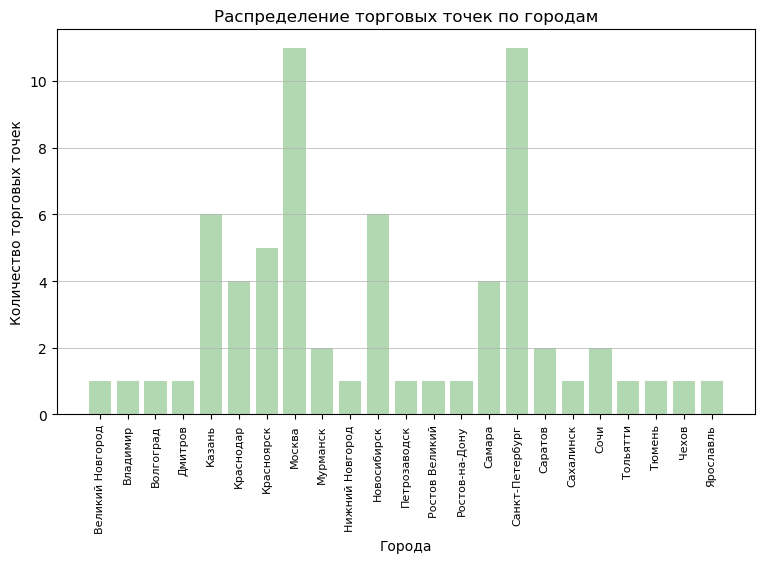

In [74]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(9, 5))
ax.bar(df_city_tp['city'], df_city_tp['tt_cnt'], alpha = .3, color = 'green')
ax.grid(axis='y', linewidth=0.5)
ax.set_xlabel('Города')
plt.xticks(fontsize = 8, rotation = 90)
ax.set_ylabel('Количество торговых точек')
ax.set_title('Распределение торговых точек по городам')
plt.show()

In [ ]:
## Торговая сеть присутствует в 23 городах, наибольшее количество торг.точек - в Москве и Санкт-Петнрбурге
## В 13 городах торговая сеть перставлена лишь 1 торговой точкой. Среднее количество торг.точек на 1 населенный пункт - 2,87

In [ ]:
## Автоматизация статистических вычислений

In [38]:
## Функция для вычисления значения t-критерия (критерия Стьюдента) и p_value для сравнения средних
def test_calc(r1, r2, alpha = 0.05):
    
    s,p = ttest_ind(r1,r2)
    
    if p < alpha:
        print("Гипотеза H0 не подтверждается: разница сравниваемых метрик статистически значима, они не равны")
        print("Разница средних значений сравниваемых метрик = ", r1.mean()-r2.mean())
    else:
        print("Гипотеза H0 подтверждается: разница сравниваемых метрик статистически НЕ значима, они равны")
        print("Разница средних значений сравниваемых метрик = 0")
        
    return s, p

In [40]:
## Функция для рассчета значения критерия Манна Уитни и p_value для сравнения распределений 
def mann_whitney_func(r1, r2, alpha=.05):
    
    s, p = mannwhitneyu(r1, r2)
    
    if p<alpha:
        print('Распределения не равны')
    else:
        print('Распределения равны')
        
    return s, p

In [ ]:
## Чистка неверно заполненных точек

In [42]:
## Формируем список всех торговых точек рабочего датафрейма
tpl = df_all_c['id_trading_point'].unique().tolist()

In [44]:
## Выводим список торговых точек, в которых в тестовой или в контрольной группе не было заплачено ни одного рубля ни одним клиентом.
tpwop = []
for i in tpl:
    for j in [0, 1]:
        if df_all_c[(df_all_c['id_trading_point'] == i) & (df_all_c['nflag_test'] == j)]['sum_pay'].sum() == 0.0:
         tpwop.append(i)
tpwopu = list(dict.fromkeys(tpwop))
print (tpwopu)

[1015, 866, 1099, 739, 46, 228, 26, 603, 810, 800, 7, 23, 4, 1, 13]


In [46]:
## Выводим список торговых точек, в которых пустует или контрольная, или тестовая группа.
tpwoc = []
for i in tpl:
    for j in [0, 1]:
        if df_all_c[(df_all_c['id_trading_point'] == i) & (df_all_c['nflag_test'] == j)]['id_client'].count() == 0.0:
         tpwoc.append(i)
tpwocu = list(dict.fromkeys(tpwoc))
print (tpwocu)

[1015, 866, 1099, 739, 228, 603, 810, 800]


In [48]:
## Объединим эти списки
tpwopc_all = list(dict.fromkeys(tpwopu + tpwocu))
print (tpwopc_all)

[1015, 866, 1099, 739, 46, 228, 26, 603, 810, 800, 7, 23, 4, 1, 13]


In [50]:
## Исключим из рассмотрения данные по торг.точкам, 
## где либо пустует или контрольная, или тестовая группа, либо в тестовой или в контрольной группе не было покупок
df_an = df_all_c[~df_all_c['id_trading_point'].isin(tpwopc_all)]

In [52]:
## Количество клиентов в получившейся рабочей выборке
df_an['id_client'].nunique()

45318

In [53]:
## Количество наблюдений в контрольной и тестовой группах в получившейся рабочей выборке
df_an['nflag_test'].value_counts()

nflag_test
0    22873
1    22445
Name: count, dtype: int64

In [94]:
## Количество отброшенных наблюдений
df_droped = df_all[df_all['id_trading_point'].isin(tpwopc_all)]
df_droped['id_client'].nunique()

10038

In [55]:
writer = pd.ExcelWriter("df_data_ready.xlsx", engine="xlsxwriter")
df_an.to_excel(writer, sheet_name="Data_ready")
writer.close()

In [96]:
df_an.describe()

,id_client,sum_pay,dtime_ad,nflag_test,id_trading_point,flag_pay
count,45318.0,45318.000000,45318,45318.000000,45318.000000,45318.000000
mean,228009.605918,2317.866852,2022-07-14 23:17:54.647861760,0.495278,1202.962002,0.521184
min,178561.0,0.000000,2022-06-03 02:47:49.183000,0.000000,2.000000,0.000000
25%,192426.25,0.000000,2022-06-24 20:46:29.189250048,0.000000,112.000000,0.000000
50%,206413.5,1175.000000,2022-07-14 20:48:29.227500032,0.000000,453.000000,1.000000
75%,262840.0,3910.000000,2022-08-03 19:26:37.676750080,1.000000,1654.000000,1.000000
max,331964.0,43083.000000,2022-08-29 00:02:17.878000,1.000000,9931.000000,1.000000
std,45298.985278,2961.049433,NaN,0.499983,1792.091001,0.499557


In [54]:
## Количество клиентов, совершивших покупки
df_an[df_an['flag_pay'] ==1]['id_client'].count()

23619

In [80]:
## Количество клиентов, не совершивших покупки
df_an[df_an['flag_pay'] ==0]['id_client'].count()

21699

In [56]:
## Выделение тестовой и контрольной групп
df_test = df_an[df_an['nflag_test']== 1]
df_control = df_an[df_an['nflag_test']== 0]

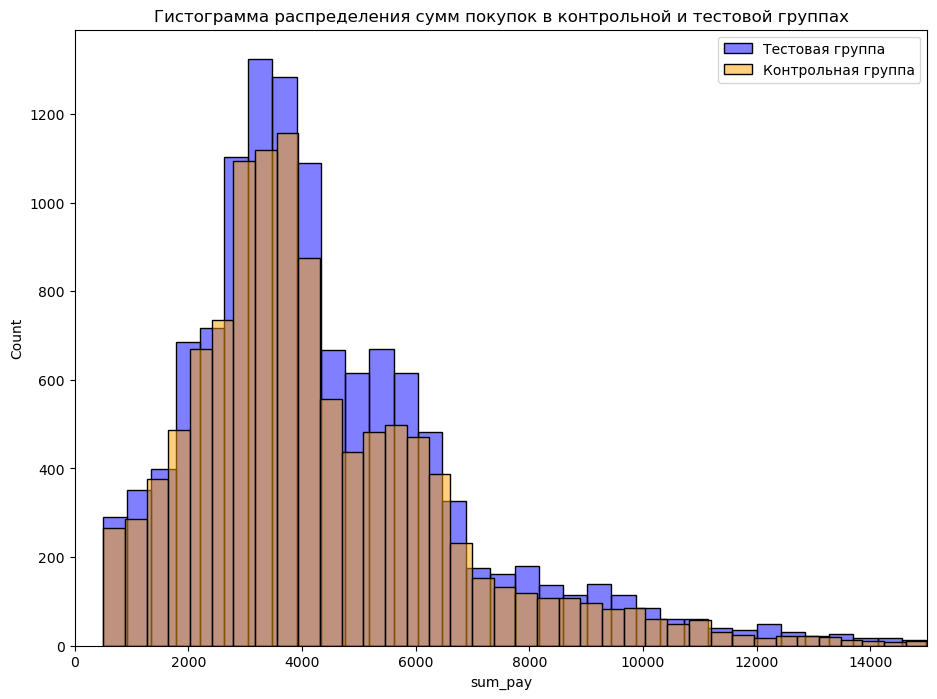

In [58]:
## Построим гистограмму распределения сумм платежей в тестовой и контрольных группах (по состоявшимся покупкам)
plt.figure(figsize=(11, 8))
plt.xlim(0, 15000) 
ax1 = sns.histplot(data=df_test[df_test['sum_pay'] != 0], x='sum_pay', bins=100, color='blue', alpha=0.5, label = 'Тестовая группа')
ax2 = sns.histplot(data=df_control[df_control['sum_pay'] != 0], x='sum_pay', bins=100, color='orange', alpha=0.5, label = 'Контрольная группа')
plt.title('Гистограмма распределения сумм покупок в контрольной и тестовой группах')
plt.legend()
plt.show()

In [ ]:
## Ручной расчет t-критерия

In [106]:
df_test['sum_pay'].mean()

2448.999019826242

In [108]:
df_control['sum_pay'].mean()

2189.1884317754557

In [110]:
df_t_m = df_test['sum_pay'].mean()
df_t_v = df_test['sum_pay'].var(ddof = 1)
n_t = len(df_test)

In [112]:
df_c_m = df_control['sum_pay'].mean()
df_c_v = df_control['sum_pay'].var(ddof = 1)
n_c = len(df_control)

In [114]:
st_cr = (df_t_m - df_c_m) / np.sqrt(df_t_v / n_t + df_c_v / n_c)
st_cr # значение t-критерия

9.34389321050735

In [116]:
## Применим функцию для сравнения средних платежей
test_calc(df_test['sum_pay'],df_control['sum_pay'], alpha = 0.05)

Гипотеза H0 не подтверждается: разница сравниваемых метрик статистически значима, они не равны
Разница средних значений сравниваемых метрик =  259.81058805078646


(9.347828066730472, 9.33995397596137e-21)

In [ ]:
# Ручной расчет z-критерия для конверсий

In [118]:
dfc_test = df_test['flag_pay'] 
m_test   = dfc_test.mean() # Среднее
var_test = dfc_test.var() # Дисперсия
n_test   = len(dfc_test) # Кол-во наблюдений 

In [120]:
m_test

0.5430162619737136

In [122]:
dfc_control = df_control['flag_pay'] 
m_control   = dfc_control.mean() # Среднее
var_control = dfc_control.var() # Дисперсия
n_control  = len(dfc_control) # Кол-во наблюдений 

In [124]:
m_control

0.49975954181786386

In [126]:
# Двухвыборочный z-критерий
st_cr_c = (m_test - m_control) / np.sqrt(var_test / n_test + var_control / n_control)
st_cr_c

9.225135454472051

In [128]:
# Конверсии не равны, так как полученное значение статистического критерия 9,225 находится в хвосте распределения. 
# Таким образом, мы отвергаем H₀.

In [130]:
## Применим функцию для сравнения конверсий
test_calc(df_test['flag_pay'],df_control['flag_pay'], alpha = 0.05)

Гипотеза H0 не подтверждается: разница сравниваемых метрик статистически значима, они не равны
Разница средних значений сравниваемых метрик =  0.04325672015584969


(9.22481186749171, 2.9589823342362546e-20)

In [132]:
mann_whitney_func(df_test['sum_pay'],df_control['sum_pay'], alpha=.05)

Распределения не равны


(269935567.5, 6.747210402232292e-24)

In [ ]:
# Проведем аналитику по сегменту Москва

In [76]:
df_test1 = df_an[(df_an['nflag_test'] == 1) & (df_an['city'] == 'Москва')]
df_control1 = df_an[(df_an['nflag_test'] == 0) & (df_an['city'] == 'Москва')]

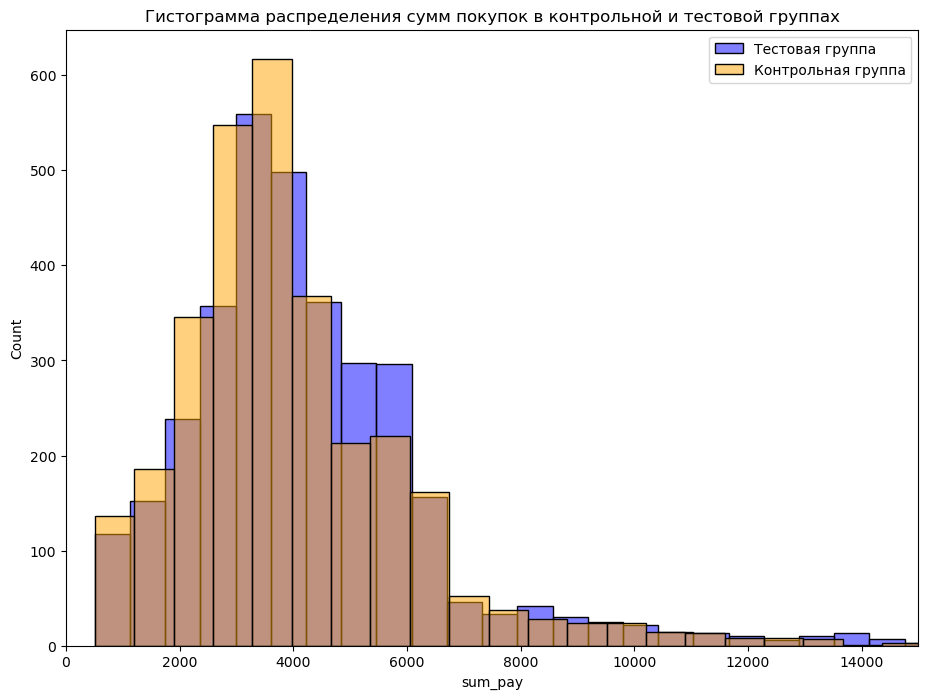

In [80]:
plt.figure(figsize=(11, 8))
plt.xlim(0, 15000) 
ax1 = sns.histplot(data=df_test1[df_test1['sum_pay'] != 0], x='sum_pay', bins=50, color='blue', alpha=0.5, label = 'Тестовая группа')
ax2 = sns.histplot(data=df_control1[df_control1['sum_pay'] != 0], x='sum_pay', bins=50, color='orange', alpha=0.5, label = 'Контрольная группа')
plt.title('Гистограмма распределения сумм покупок в контрольной и тестовой группах')
plt.legend()
plt.show()

In [140]:
# Сравнение средних платежей
test_calc(df_test1['sum_pay'],df_control1['sum_pay'], alpha = 0.05)

Гипотеза H0 не подтверждается: разница сравниваемых метрик статистически значима, они не равны
Разница средних значений сравниваемых метрик =  370.94656883165453


(7.48508673623881, 7.634481718577209e-14)

In [142]:
# Сравнение конверсий в покупку
test_calc(df_test1['flag_pay'],df_control1['flag_pay'], alpha = 0.05)

Гипотеза H0 не подтверждается: разница сравниваемых метрик статистически значима, они не равны
Разница средних значений сравниваемых метрик =  0.054599851390915666


(6.080854526449197, 1.2307191818895714e-09)

In [144]:
# Сравнение распределений средних платежей
mann_whitney_func(df_test1['sum_pay'],df_control1['sum_pay'], alpha=.05)

Распределения не равны


(20567312.5, 2.366136885947099e-15)

In [ ]:
# Проведем аналитику по сегменту Санкт-Петербург

In [60]:
df_test2 = df_an[(df_an['nflag_test'] == 1) & (df_an['city'] == 'Санкт-Петербург')]
df_control2 = df_an[(df_an['nflag_test'] == 0) & (df_an['city'] == 'Санкт-Петербург')]

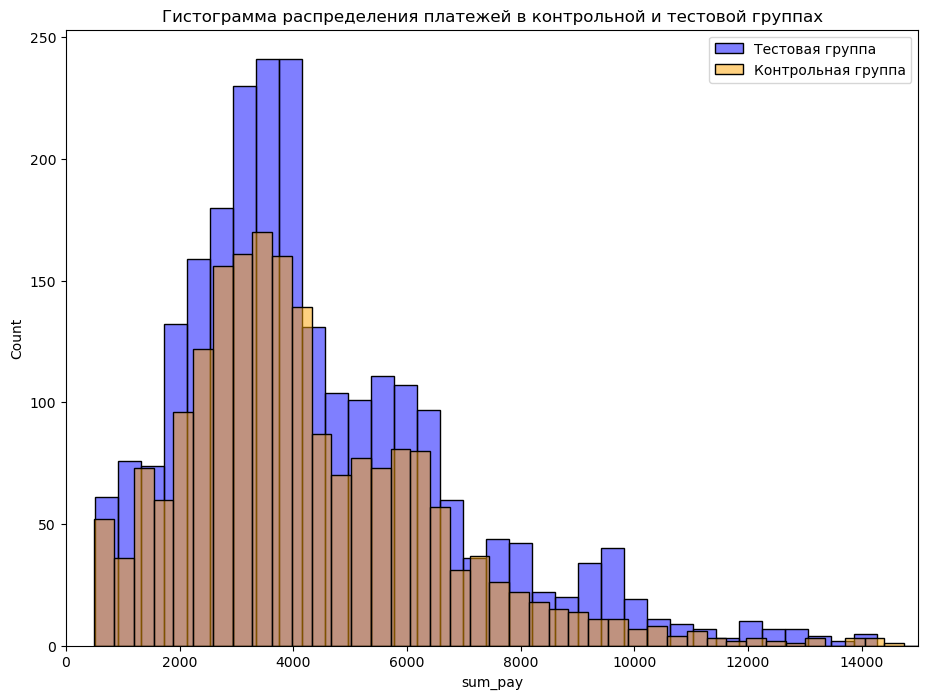

In [62]:
plt.figure(figsize=(11, 8))
plt.xlim(0, 15000) 
ax1 = sns.histplot(data=df_test2[df_test2['sum_pay'] != 0], x='sum_pay', bins=50, color='blue', alpha=0.5, label = 'Тестовая группа')
ax2 = sns.histplot(data=df_control2[df_control2['sum_pay'] != 0], x='sum_pay', bins=50, color='orange', alpha=0.5, label = 'Контрольная группа')
plt.title('Гистограмма распределения платежей в контрольной и тестовой группах')
plt.legend()
plt.show()

In [ ]:
## Это код для экспорта графика в файл в формате png. Вставлять перед plt.show()
# plt.savefig('otchet_Spb.png',
#            dpi=300,
#            bbox_inches='tight'
#            )

# plt.close()

In [150]:
# Сравнение средних платежей
test_calc(df_test2['sum_pay'],df_control2['sum_pay'], alpha = 0.05)

Гипотеза H0 не подтверждается: разница сравниваемых метрик статистически значима, они не равны
Разница средних значений сравниваемых метрик =  513.9039043833998


(8.759635784179547, 2.3198088937974163e-18)

In [152]:
# Сравнение конверсий в покупку
test_calc(df_test2['flag_pay'],df_control2['flag_pay'], alpha = 0.05)

Гипотеза H0 не подтверждается: разница сравниваемых метрик статистически значима, они не равны
Разница средних значений сравниваемых метрик =  0.09877797751600403


(9.352468686561785, 1.065825659919673e-20)

In [154]:
# Сравнение распределений средних платежей
mann_whitney_func(df_test2['sum_pay'],df_control2['sum_pay'], alpha=.05)

Распределения не равны


(10899685.5, 2.0392184217953754e-20)

Т.о. и в целом по выборке, и отдельно в Москве и в Санкт-Петербурге отмечается статистически значимый рост
как средней суммы платежа, так и конверсии в тестовой выборке.
Значит эксперимент с пуш-уведомлениями показал положительный результат в этих городах и в целом по сети.

In [ ]:
## Теперь проверим результаты эксперимента по остальным городам

In [86]:
city_list = df_an['city'].unique().tolist()
city_list.remove('Москва')
city_list.remove('Санкт-Петербург')
city_list # список остальных городов присутствия

['Красноярск',
 'Мурманск',
 'Казань',
 'Саратов',
 'Тольятти',
 'Тюмень',
 'Волгоград',
 'Сочи',
 'Владимир',
 'Самара',
 'Краснодар',
 'Сахалинск',
 'Дмитров']

In [106]:
from matplotlib.backends.backend_pdf import PdfPages
pdf = PdfPages('множество_графиков.pdf')

In [108]:
for city in city_list:
    df_t = df_an[(df_an['nflag_test']==1) & (df_an['city']==city)]
    df_c = df_an[(df_an['nflag_test']==0) & (df_an['city']==city)]
    fig, ax = plt.subplots(figsize=(9, 6))
    ax1 = sns.histplot(data=df_t[df_t['sum_pay'] != 0], x='sum_pay', bins=30, color='blue', alpha=0.5, label = 'Тестовая группа')
    ax2 = sns.histplot(data=df_c[df_c['sum_pay'] != 0], x='sum_pay', bins=30, color='orange', alpha=0.5, label = 'Контрольная группа')
    ax.set_title(f'Гистограмма распределения платежей в контрольной и тестовой группах в городе {city}')
    ax.legend()
    pdf.savefig(fig)
    plt.close()
pdf.close()

Красноярск
Сравнение средних платежей в тестовой и контрольной группах:
Гипотеза H0 подтверждается: разница сравниваемых метрик статистически НЕ значима, они равны
Разница средних значений сравниваемых метрик = 0
Сравнение конверсий в покупку в тестовой и контрольной группах:
Гипотеза H0 подтверждается: разница сравниваемых метрик статистически НЕ значима, они равны
Разница средних значений сравниваемых метрик = 0
Сравнение распределений средних платежей в тестовой и контрольной группах:
Распределения равны


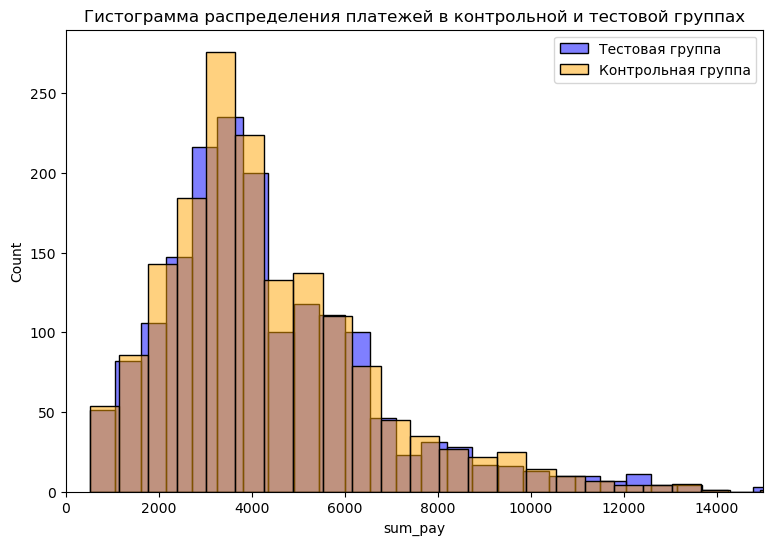

Мурманск
Сравнение средних платежей в тестовой и контрольной группах:
Гипотеза H0 подтверждается: разница сравниваемых метрик статистически НЕ значима, они равны
Разница средних значений сравниваемых метрик = 0
Сравнение конверсий в покупку в тестовой и контрольной группах:
Гипотеза H0 подтверждается: разница сравниваемых метрик статистически НЕ значима, они равны
Разница средних значений сравниваемых метрик = 0
Сравнение распределений средних платежей в тестовой и контрольной группах:
Распределения равны


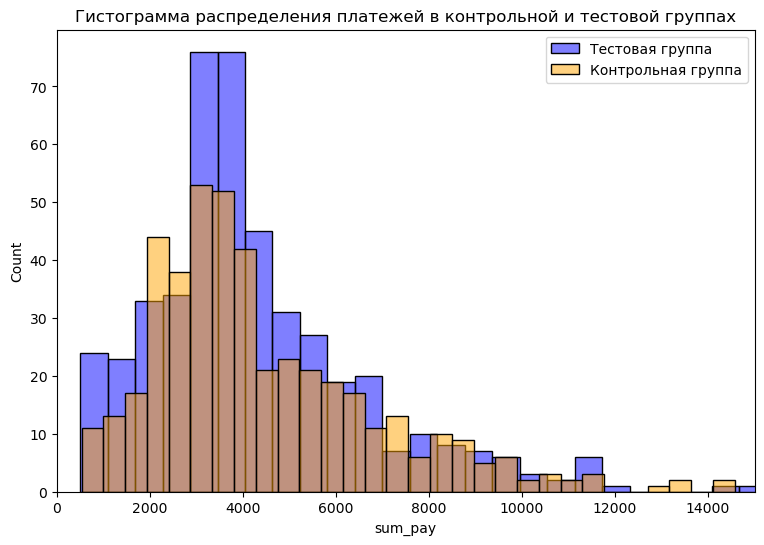

Казань
Сравнение средних платежей в тестовой и контрольной группах:
Гипотеза H0 подтверждается: разница сравниваемых метрик статистически НЕ значима, они равны
Разница средних значений сравниваемых метрик = 0
Сравнение конверсий в покупку в тестовой и контрольной группах:
Гипотеза H0 подтверждается: разница сравниваемых метрик статистически НЕ значима, они равны
Разница средних значений сравниваемых метрик = 0
Сравнение распределений средних платежей в тестовой и контрольной группах:
Распределения равны


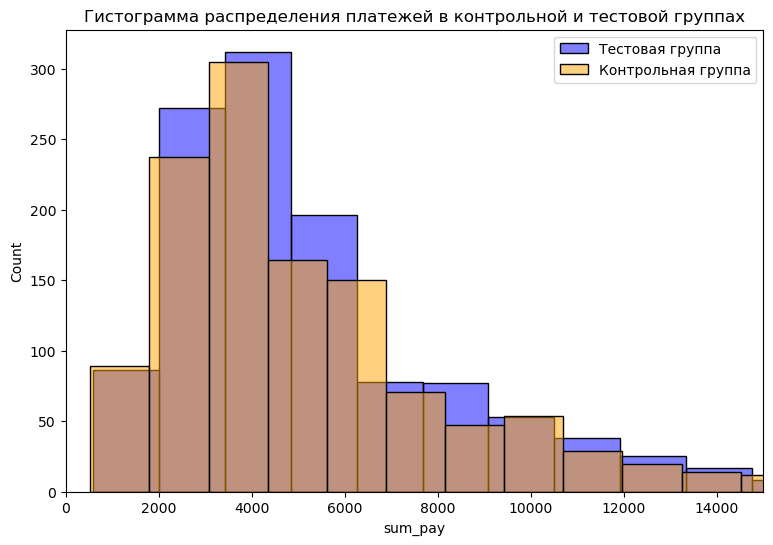

Саратов
Сравнение средних платежей в тестовой и контрольной группах:
Гипотеза H0 подтверждается: разница сравниваемых метрик статистически НЕ значима, они равны
Разница средних значений сравниваемых метрик = 0
Сравнение конверсий в покупку в тестовой и контрольной группах:
Гипотеза H0 подтверждается: разница сравниваемых метрик статистически НЕ значима, они равны
Разница средних значений сравниваемых метрик = 0
Сравнение распределений средних платежей в тестовой и контрольной группах:
Распределения равны


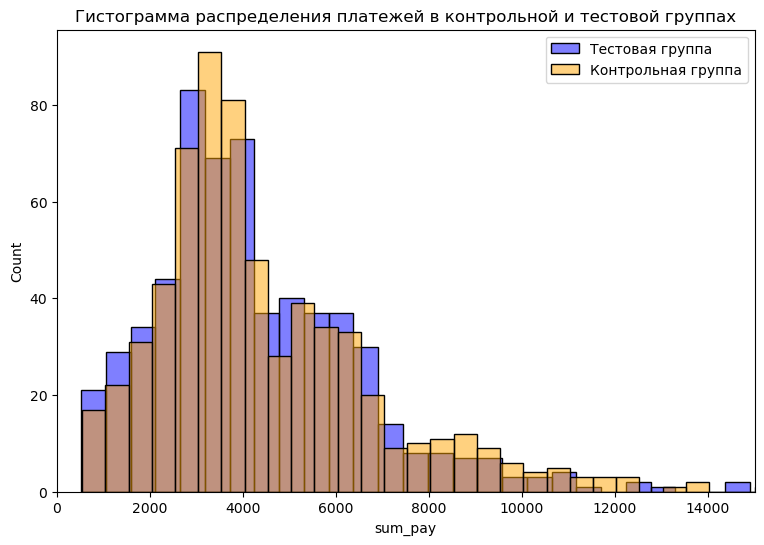

Тольятти
Сравнение средних платежей в тестовой и контрольной группах:
Гипотеза H0 подтверждается: разница сравниваемых метрик статистически НЕ значима, они равны
Разница средних значений сравниваемых метрик = 0
Сравнение конверсий в покупку в тестовой и контрольной группах:
Гипотеза H0 подтверждается: разница сравниваемых метрик статистически НЕ значима, они равны
Разница средних значений сравниваемых метрик = 0
Сравнение распределений средних платежей в тестовой и контрольной группах:
Распределения равны


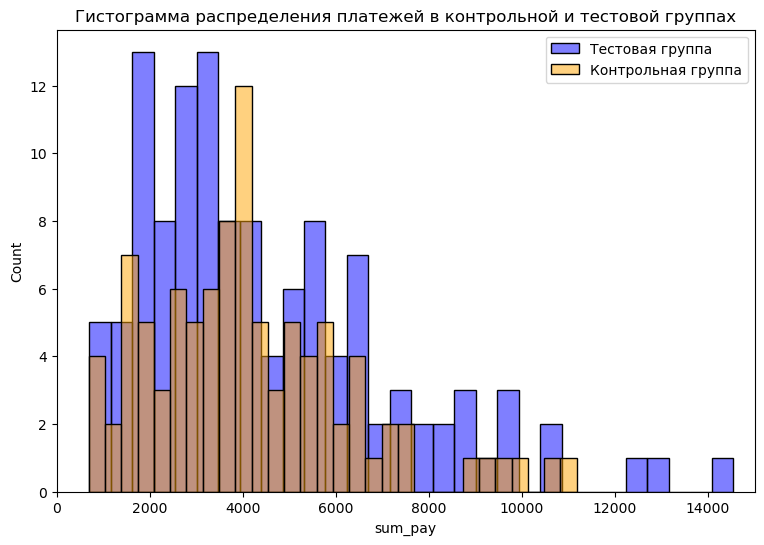

Тюмень
Сравнение средних платежей в тестовой и контрольной группах:
Гипотеза H0 подтверждается: разница сравниваемых метрик статистически НЕ значима, они равны
Разница средних значений сравниваемых метрик = 0
Сравнение конверсий в покупку в тестовой и контрольной группах:
Гипотеза H0 не подтверждается: разница сравниваемых метрик статистически значима, они не равны
Разница средних значений сравниваемых метрик =  0.1463645943097998
Сравнение распределений средних платежей в тестовой и контрольной группах:
Распределения не равны


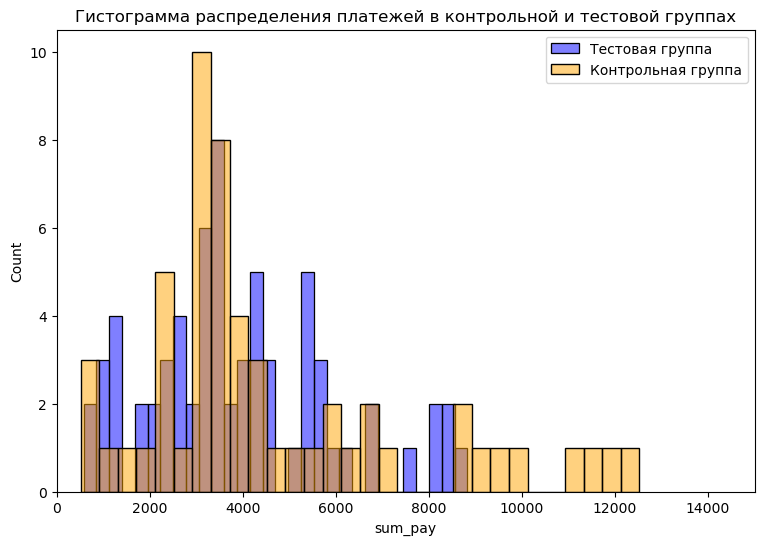

Волгоград
Сравнение средних платежей в тестовой и контрольной группах:
Гипотеза H0 не подтверждается: разница сравниваемых метрик статистически значима, они не равны
Разница средних значений сравниваемых метрик =  -312.89040013337035
Сравнение конверсий в покупку в тестовой и контрольной группах:
Гипотеза H0 подтверждается: разница сравниваемых метрик статистически НЕ значима, они равны
Разница средних значений сравниваемых метрик = 0
Сравнение распределений средних платежей в тестовой и контрольной группах:
Распределения не равны


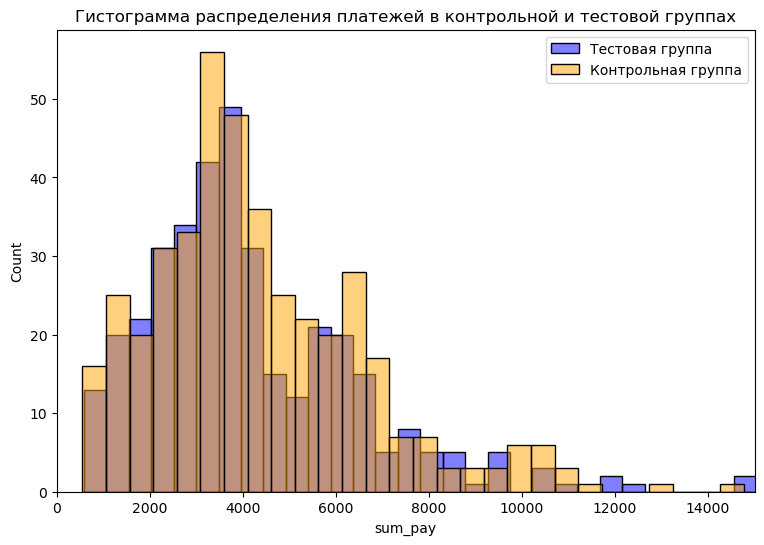

Сочи
Сравнение средних платежей в тестовой и контрольной группах:
Гипотеза H0 подтверждается: разница сравниваемых метрик статистически НЕ значима, они равны
Разница средних значений сравниваемых метрик = 0
Сравнение конверсий в покупку в тестовой и контрольной группах:
Гипотеза H0 не подтверждается: разница сравниваемых метрик статистически значима, они не равны
Разница средних значений сравниваемых метрик =  -0.04931605920420967
Сравнение распределений средних платежей в тестовой и контрольной группах:
Распределения равны


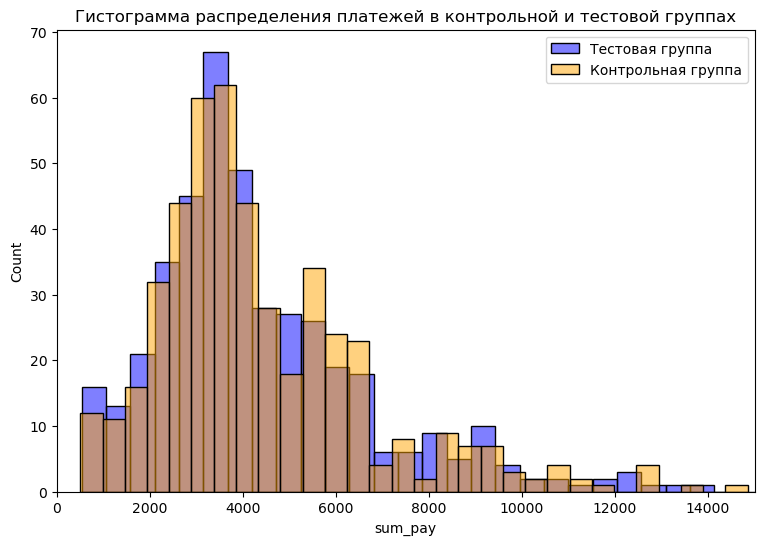

Владимир
Сравнение средних платежей в тестовой и контрольной группах:
Гипотеза H0 не подтверждается: разница сравниваемых метрик статистически значима, они не равны
Разница средних значений сравниваемых метрик =  438.6098419243094
Сравнение конверсий в покупку в тестовой и контрольной группах:
Гипотеза H0 подтверждается: разница сравниваемых метрик статистически НЕ значима, они равны
Разница средних значений сравниваемых метрик = 0
Сравнение распределений средних платежей в тестовой и контрольной группах:
Распределения не равны


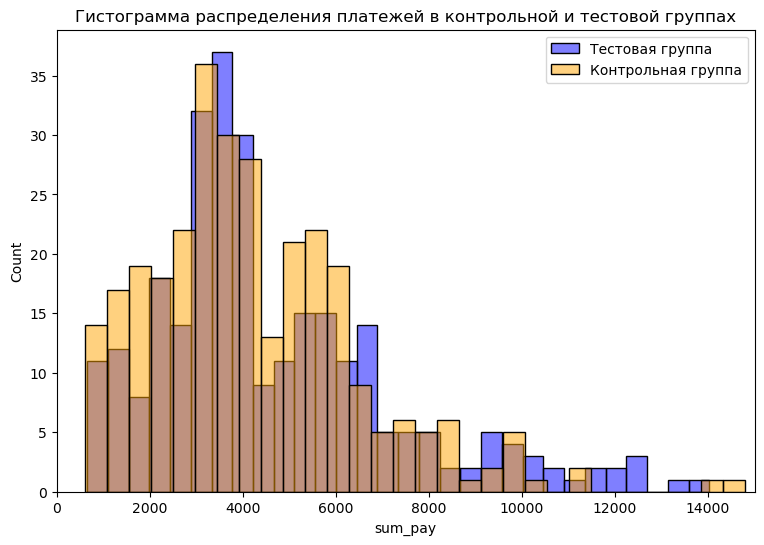

Самара
Сравнение средних платежей в тестовой и контрольной группах:
Гипотеза H0 не подтверждается: разница сравниваемых метрик статистически значима, они не равны
Разница средних значений сравниваемых метрик =  1544.3720191247648
Сравнение конверсий в покупку в тестовой и контрольной группах:
Гипотеза H0 не подтверждается: разница сравниваемых метрик статистически значима, они не равны
Разница средних значений сравниваемых метрик =  0.2772412939282998
Сравнение распределений средних платежей в тестовой и контрольной группах:
Распределения не равны


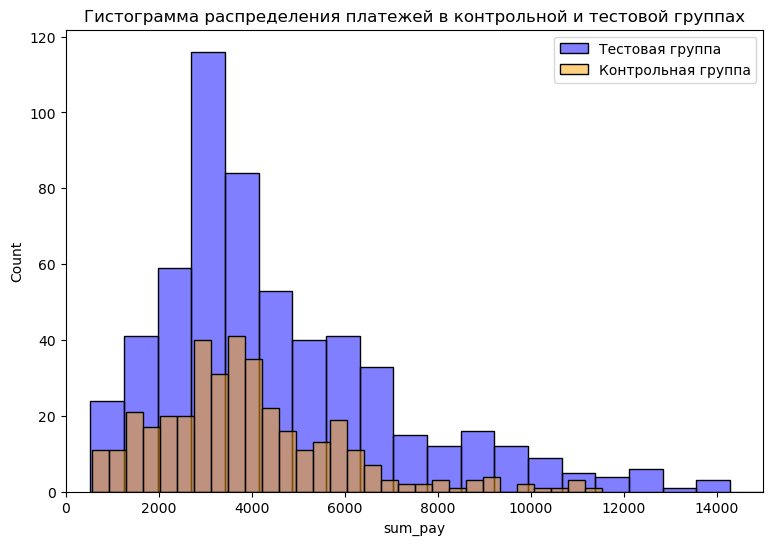

Краснодар
Сравнение средних платежей в тестовой и контрольной группах:
Гипотеза H0 подтверждается: разница сравниваемых метрик статистически НЕ значима, они равны
Разница средних значений сравниваемых метрик = 0
Сравнение конверсий в покупку в тестовой и контрольной группах:
Гипотеза H0 подтверждается: разница сравниваемых метрик статистически НЕ значима, они равны
Разница средних значений сравниваемых метрик = 0
Сравнение распределений средних платежей в тестовой и контрольной группах:
Распределения равны


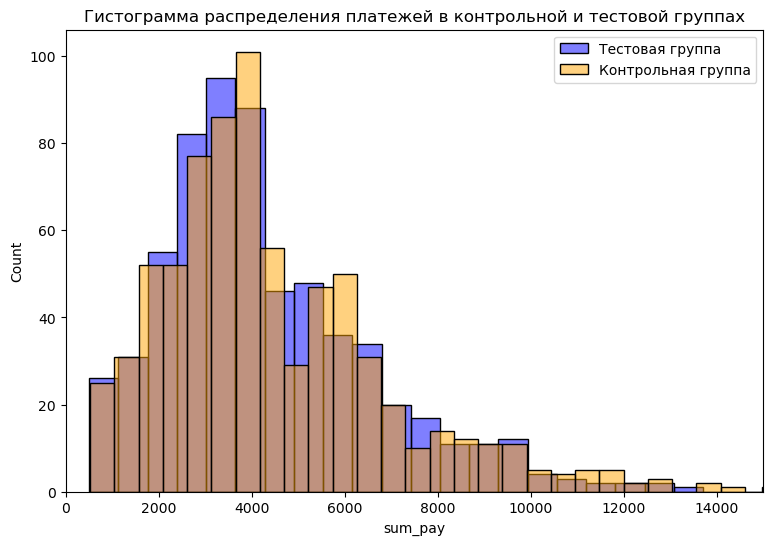

Сахалинск
Сравнение средних платежей в тестовой и контрольной группах:
Гипотеза H0 подтверждается: разница сравниваемых метрик статистически НЕ значима, они равны
Разница средних значений сравниваемых метрик = 0
Сравнение конверсий в покупку в тестовой и контрольной группах:
Гипотеза H0 подтверждается: разница сравниваемых метрик статистически НЕ значима, они равны
Разница средних значений сравниваемых метрик = 0
Сравнение распределений средних платежей в тестовой и контрольной группах:
Распределения равны


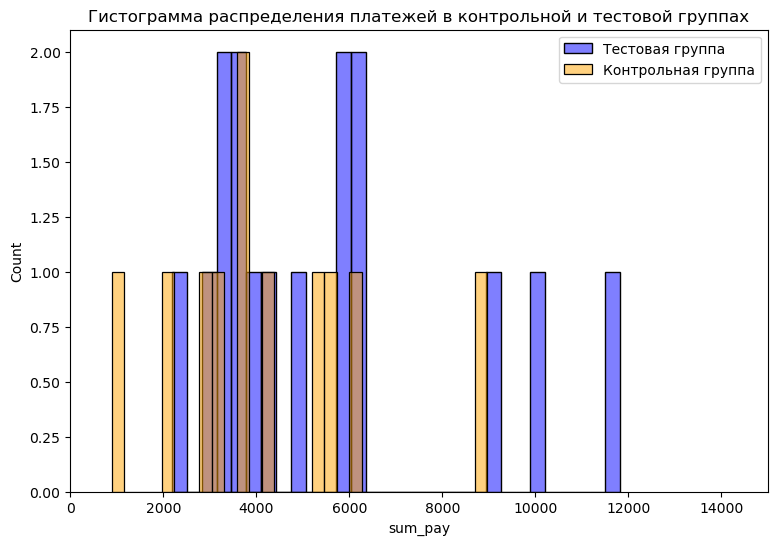

Дмитров
Сравнение средних платежей в тестовой и контрольной группах:
Гипотеза H0 подтверждается: разница сравниваемых метрик статистически НЕ значима, они равны
Разница средних значений сравниваемых метрик = 0
Сравнение конверсий в покупку в тестовой и контрольной группах:
Гипотеза H0 подтверждается: разница сравниваемых метрик статистически НЕ значима, они равны
Разница средних значений сравниваемых метрик = 0
Сравнение распределений средних платежей в тестовой и контрольной группах:
Распределения равны


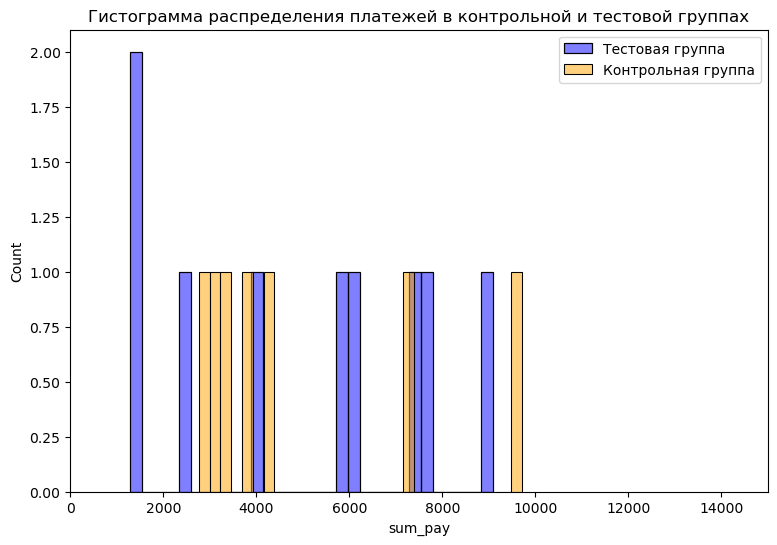

In [94]:
for city in city_list:
    print(city)
    df_t = df_an[(df_an['nflag_test']==1) & (df_an['city']==city)]
    df_c = df_an[(df_an['nflag_test']==0) & (df_an['city']==city)]
    print ('Сравнение средних платежей в тестовой и контрольной группах:')
    test_calc(df_t['sum_pay'],df_c['sum_pay'], alpha = 0.05)
    print ('Сравнение конверсий в покупку в тестовой и контрольной группах:')
    test_calc(df_t['flag_pay'],df_c['flag_pay'], alpha = 0.05)
    print ('Сравнение распределений средних платежей в тестовой и контрольной группах:')
    mann_whitney_func(df_t['sum_pay'],df_c['sum_pay'], alpha = 0.05)
    plt.figure(figsize=(9, 6))
    plt.xlim(0, 15000) 
    ax1 = sns.histplot(data=df_t[df_t['sum_pay'] != 0], x='sum_pay', bins=30, color='blue', alpha=0.5, label = 'Тестовая группа')
    ax2 = sns.histplot(data=df_c[df_c['sum_pay'] != 0], x='sum_pay', bins=30, color='orange', alpha=0.5, label = 'Контрольная группа')
    plt.title('Гистограмма распределения платежей в контрольной и тестовой группах')
    plt.legend()
    plt.show()

В большинстве городов (кроме столиц) эксперимент практически не повлиял на исследуемые метрики
Лишь в Самаре проведенный экперимент дал значимый рост как средней суммы покупки, так и конверсии в покупку
В Тюмени конверсия выросла, а в Сочи конверсия упала при стабильной средней сумме покупки и там, и там
Во Владимире выросла средняя сумма покупки, а в Волгограде - упала при незначимом изменении конверсии в покупку

In [114]:
## Сформируем датафрейм с результатами эксперимента по всем городам
df_result_cities = pd.DataFrame(columns = ['city', 'count_test', 'count_control', 'count_all', 'percent_count',\
                         'avg_payment_test', 'avg_payment_control', 'diff', 'sigma_test', 'sigma_control', 'ttest_sumpay', 'pvalue_ttest_sumpay',\
                                          'ttest_conv', 'pvalue_ttest_conv', 'mw_sumpay', 'pvalue_mw_sumpay'])
df_result_cities

,city,count_test,count_control,count_all,percent_count,avg_payment_test,avg_payment_control,diff,sigma_test,sigma_control,ttest_sumpay,pvalue_ttest_sumpay,ttest_conv,pvalue_ttest_conv,mw_sumpay,pvalue_mw_sumpay


In [122]:
for i in df_an['city'].unique():
    city_info=[]
    city_info.append(i)
    df_t = df_an[(df_an['nflag_test']==1) & (df_an['city']==i)]
    df_c = df_an[(df_an['nflag_test']==0) & (df_an['city']==i)]
    city_info.append(df_t['id_client'].count())
    city_info.append(df_c['id_client'].count())
    city_info.append(df_an[df_an['city'] == i]['id_client'].count())
    city_info.append(df_an[df_an['city'] == i]['id_client'].count() / df_an['id_client'].count() *100)
    city_info.append(df_t['sum_pay'].mean())
    city_info.append(df_c['sum_pay'].mean())
    city_info.append(df_t['sum_pay'].mean() - df_c['sum_pay'].mean())
    city_info.append(np.sqrt(df_t['sum_pay'].var()))
    city_info.append(np.sqrt(df_c['sum_pay'].var()))
    s_sp,p_sp = ttest_ind(df_t['sum_pay'], df_c['sum_pay'])
    city_info.append(s_sp)
    city_info.append(p_sp)
    s_conv,p_conv = ttest_ind(df_t['flag_pay'],df_c['flag_pay'])
    city_info.append(s_conv)
    city_info.append(p_conv)
    s_mw_sp, p_mw_sp = mannwhitneyu(df_t['sum_pay'],df_c['sum_pay'])
    city_info.append(s_mw_sp)
    city_info.append(p_mw_sp)
    df_result_cities.loc[len(df_result_cities)] = city_info
df_result_cities
## Наполнение цикла - в соответствии со схемой в задании 

,city,count_test,count_control,count_all,percent_count,avg_payment_test,avg_payment_control,diff,sigma_test,sigma_control,ttest_sumpay,pvalue_ttest_sumpay,ttest_conv,pvalue_ttest_conv,mw_sumpay,pvalue_mw_sumpay
0,Красноярск,3037,2900,5937,13.100755,2437.495884,2428.777586,8.718298,2824.714867,2769.994132,0.120006,9.044824e-01,-0.278636,7.805337e-01,4393882.0,8.770470e-01
1,Мурманск,1055,1065,2120,4.678053,1865.271090,1857.219718,8.051372,2663.933863,2706.345749,0.069025,9.449762e-01,0.846011,3.976423e-01,569507.5,5.434252e-01
2,Казань,2500,2577,5077,11.203054,2731.913200,2610.688397,121.224803,4116.451867,3989.993669,1.065527,2.866880e-01,0.273045,7.848298e-01,3263925.0,3.772600e-01
3,Санкт-Петербург,4445,4434,8879,19.592656,2427.462542,1913.558638,513.903904,2880.109268,2642.613816,8.759636,2.319809e-18,9.352469,1.065826e-20,10899685.5,2.039218e-20
4,Москва,6134,6224,12358,27.269518,2357.127160,1986.180591,370.946569,2853.228628,2653.664282,7.485087,7.634482e-14,6.080855,1.230719e-09,20567312.5,2.366137e-15
5,Саратов,1013,1109,2122,4.682466,2528.788746,2541.645627,-12.856880,2776.177103,2845.897352,-0.105169,9.162513e-01,0.650785,5.152558e-01,565440.5,7.833258e-01
6,Тольятти,190,167,357,0.787766,2902.410526,2439.461078,462.949448,3074.648887,2689.343053,1.504556,1.333273e-01,1.185144,2.367531e-01,17020.5,2.213418e-01
7,Тюмень,130,146,276,0.609030,2043.823077,1743.376712,300.446365,2442.266788,2891.333359,0.926459,3.550228e-01,2.459825,1.451826e-02,10741.0,3.806622e-02
8,Волгоград,657,703,1360,3.001015,2288.870624,2601.761024,-312.890400,2682.567610,2830.193773,-2.089272,3.686900e-02,-1.622217,1.049889e-01,216128.0,3.323940e-02
9,Сочи,796,806,1602,3.535019,2305.830402,2523.081886,-217.251484,2823.833143,2810.777017,-1.543216,1.229761e-01,-1.984956,4.731989e-02,303988.5,5.698257e-02


In [126]:
## Расстановка меток по результатам эксперимента
df_result_cities['label_sumpay'] = np.where((df_result_cities['pvalue_ttest_sumpay'] < 0.05) & (df_result_cities['diff'] > 0 ), 'positive', \
                              np.where((df_result_cities['pvalue_ttest_sumpay'] < 0.05) & (df_result_cities['diff'] < 0), 'negative', 'neutral'))
df_result_cities['label_conv'] = np.where((df_result_cities['pvalue_ttest_conv'] < 0.05) & (df_result_cities['ttest_conv'] > 0 ), 'positive', \
                              np.where((df_result_cities['pvalue_ttest_conv'] < 0.05) & (df_result_cities['ttest_conv'] < 0), 'negative', 'neutral'))
df_result_cities

,city,count_test,count_control,count_all,percent_count,avg_payment_test,avg_payment_control,diff,sigma_test,sigma_control,ttest_sumpay,pvalue_ttest_sumpay,ttest_conv,pvalue_ttest_conv,mw_sumpay,pvalue_mw_sumpay,label_sumpay,label_conv
0,Красноярск,3037,2900,5937,13.100755,2437.495884,2428.777586,8.718298,2824.714867,2769.994132,0.120006,9.044824e-01,-0.278636,7.805337e-01,4393882.0,8.770470e-01,neutral,neutral
1,Мурманск,1055,1065,2120,4.678053,1865.271090,1857.219718,8.051372,2663.933863,2706.345749,0.069025,9.449762e-01,0.846011,3.976423e-01,569507.5,5.434252e-01,neutral,neutral
2,Казань,2500,2577,5077,11.203054,2731.913200,2610.688397,121.224803,4116.451867,3989.993669,1.065527,2.866880e-01,0.273045,7.848298e-01,3263925.0,3.772600e-01,neutral,neutral
3,Санкт-Петербург,4445,4434,8879,19.592656,2427.462542,1913.558638,513.903904,2880.109268,2642.613816,8.759636,2.319809e-18,9.352469,1.065826e-20,10899685.5,2.039218e-20,positive,positive
4,Москва,6134,6224,12358,27.269518,2357.127160,1986.180591,370.946569,2853.228628,2653.664282,7.485087,7.634482e-14,6.080855,1.230719e-09,20567312.5,2.366137e-15,positive,positive
5,Саратов,1013,1109,2122,4.682466,2528.788746,2541.645627,-12.856880,2776.177103,2845.897352,-0.105169,9.162513e-01,0.650785,5.152558e-01,565440.5,7.833258e-01,neutral,neutral
6,Тольятти,190,167,357,0.787766,2902.410526,2439.461078,462.949448,3074.648887,2689.343053,1.504556,1.333273e-01,1.185144,2.367531e-01,17020.5,2.213418e-01,neutral,neutral
7,Тюмень,130,146,276,0.609030,2043.823077,1743.376712,300.446365,2442.266788,2891.333359,0.926459,3.550228e-01,2.459825,1.451826e-02,10741.0,3.806622e-02,neutral,positive
8,Волгоград,657,703,1360,3.001015,2288.870624,2601.761024,-312.890400,2682.567610,2830.193773,-2.089272,3.686900e-02,-1.622217,1.049889e-01,216128.0,3.323940e-02,negative,neutral
9,Сочи,796,806,1602,3.535019,2305.830402,2523.081886,-217.251484,2823.833143,2810.777017,-1.543216,1.229761e-01,-1.984956,4.731989e-02,303988.5,5.698257e-02,neutral,negative


In [128]:
writer = pd.ExcelWriter("pandas_dfresult_cities.xlsx", engine="xlsxwriter")
df_result_cities.to_excel(writer, sheet_name="Results_Cities")
writer.close()

In [168]:
# Формируем датафрейм с результатами эксперимента по всем торговым точкам
df_result = pd.DataFrame(columns = ['city', 'id_trading_point', 'count_test', 'count_control', 'count_all', 'percent_count',\
                         'avg_payment_test', 'avg_payment_control', 'diff', 'sigma_test', 'sigma_control', 'ttest', 'pvalue_ttest'])
df_result

,city,id_trading_point,count_test,count_control,count_all,percent_count,avg_payment_test,avg_payment_control,diff,sigma_test,sigma_control,ttest,pvalue_ttest


In [170]:
for i in df_an['city'].unique():
    for j in df_an[df_an['city']==i]['id_trading_point'].unique().tolist():
        tt_info=[]
        tt_info.append(i)
        tt_info.append(j)
        df_t = df_an[(df_an['nflag_test']==1) & (df_an['city']==i)&(df_an['id_trading_point']==j)]
        df_c = df_an[(df_an['nflag_test']==0) & (df_an['city']==i)&(df_an['id_trading_point']==j)]
        tt_info.append(df_t['id_client'].count())
        tt_info.append(df_c['id_client'].count())
        tt_info.append(df_an[(df_an['city'] == i) & (df_an['id_trading_point'] == j)]['id_client'].count())
        tt_info.append(df_an[(df_an['city'] == i) & (df_an['id_trading_point'] == j)]['id_client'].count() / df_an['id_client'].count() *100)
        tt_info.append(df_t['sum_pay'].mean())
        tt_info.append(df_c['sum_pay'].mean())
        tt_info.append(df_t['sum_pay'].mean() - df_c['sum_pay'].mean())
        tt_info.append(np.sqrt(df_t['sum_pay'].var()))
        tt_info.append(np.sqrt(df_c['sum_pay'].var()))
        s,p = ttest_ind(df_t['sum_pay'], df_c['sum_pay'])
        tt_info.append(s)
        tt_info.append(p)
        df_result.loc[len(df_result)] = tt_info
df_result
## Наполнение цикла - в соответствии со схемой в задании 

,city,id_trading_point,count_test,count_control,count_all,percent_count,avg_payment_test,avg_payment_control,diff,sigma_test,sigma_control,ttest,pvalue_ttest
0,Красноярск,212,593,575,1168,2.577342,2144.317032,2222.052174,-77.735142,2708.588724,2785.116250,-0.483585,6.287709e-01
1,Красноярск,278,535,489,1024,2.259588,2499.345794,2185.214724,314.131070,2915.995329,2574.915597,1.820268,6.901056e-02
2,Красноярск,202,551,565,1116,2.462598,2927.341198,2730.378761,196.962437,2956.686241,2737.885785,1.155073,2.483083e-01
3,Красноярск,444,650,562,1212,2.674434,2404.106154,2545.734875,-141.628722,2810.828487,2797.138764,-0.876740,3.808017e-01
4,Красноярск,277,708,709,1417,3.126793,2285.750000,2431.365303,-145.615303,2712.677878,2868.587569,-0.981705,3.264128e-01
5,Мурманск,54,633,640,1273,2.809038,1702.714060,1688.512500,14.201560,2565.132440,2628.012490,0.097556,9.223005e-01
6,Мурманск,55,422,425,847,1.869015,2109.106635,2111.272941,-2.166306,2790.993385,2804.223188,-0.011268,9.910125e-01
7,Казань,991,270,294,564,1.244539,3249.281481,2452.986395,796.295087,4719.592601,3633.935858,2.255258,2.450100e-02
8,Казань,699,482,494,976,2.153670,2422.286307,2574.352227,-152.065920,3906.817897,4082.851356,-0.594254,5.524804e-01
9,Казань,477,382,386,768,1.694691,2259.623037,2496.987047,-237.364010,3482.846094,3881.994719,-0.891593,3.728909e-01


In [172]:
## Количество городов, результаты которых вошли в отчет
df_result['city'].nunique()

15

In [174]:
## Количество торговых точек, результаты которых вошли в отчет
df_result['id_trading_point'].count()

51

In [185]:
## Расстановка меток по результатам эксперимента
df_result['label'] = np.where((df_result['pvalue_ttest'] < 0.05) & (df_result['diff'] > 0 ), 'positive', \
                              np.where((df_result['pvalue_ttest'] < 0.05) & (df_result['diff'] < 0), 'negative', 'neutral'))
df_result

,city,id_trading_point,count_test,count_control,count_all,percent_count,avg_payment_test,avg_payment_control,diff,sigma_test,sigma_control,ttest,pvalue_ttest,lebel,label
0,Красноярск,212,593,575,1168,2.577342,2144.317032,2222.052174,-77.735142,2708.588724,2785.116250,-0.483585,6.287709e-01,neutral,neutral
1,Красноярск,278,535,489,1024,2.259588,2499.345794,2185.214724,314.131070,2915.995329,2574.915597,1.820268,6.901056e-02,neutral,neutral
2,Красноярск,202,551,565,1116,2.462598,2927.341198,2730.378761,196.962437,2956.686241,2737.885785,1.155073,2.483083e-01,neutral,neutral
3,Красноярск,444,650,562,1212,2.674434,2404.106154,2545.734875,-141.628722,2810.828487,2797.138764,-0.876740,3.808017e-01,neutral,neutral
4,Красноярск,277,708,709,1417,3.126793,2285.750000,2431.365303,-145.615303,2712.677878,2868.587569,-0.981705,3.264128e-01,neutral,neutral
5,Мурманск,54,633,640,1273,2.809038,1702.714060,1688.512500,14.201560,2565.132440,2628.012490,0.097556,9.223005e-01,neutral,neutral
6,Мурманск,55,422,425,847,1.869015,2109.106635,2111.272941,-2.166306,2790.993385,2804.223188,-0.011268,9.910125e-01,neutral,neutral
7,Казань,991,270,294,564,1.244539,3249.281481,2452.986395,796.295087,4719.592601,3633.935858,2.255258,2.450100e-02,positive,positive
8,Казань,699,482,494,976,2.153670,2422.286307,2574.352227,-152.065920,3906.817897,4082.851356,-0.594254,5.524804e-01,neutral,neutral
9,Казань,477,382,386,768,1.694691,2259.623037,2496.987047,-237.364010,3482.846094,3881.994719,-0.891593,3.728909e-01,neutral,neutral


In [598]:
## Выгрузка в Excel

In [187]:
df_result_pos = df_result[df_result['label'] == 'positive']
df_result_neg = df_result[df_result['label'] == 'negative']
df_result_neu = df_result[df_result['label'] == 'neutral']

In [191]:
writer = pd.ExcelWriter("pandas_dfresult.xlsx", engine="xlsxwriter")
df_result.to_excel(writer, sheet_name="Total")
df_result_pos.to_excel(writer, sheet_name="Positive")
df_result_neg.to_excel(writer, sheet_name="Negative")
df_result_neu.to_excel(writer, sheet_name="Neutral")
writer.close()